In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

In [2]:
df_bikes=pd.read_csv("D:\לימודים יד\בינה מלאכותית\מבחן\day.csv")

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\dassi\AppData\Local\Temp\ipykernel_7636\3674968371.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df_bikes=pd.read_csv("D:\לימודים יד\בינה מלאכותית\מבחן\day.csv")


In [3]:
df_bikes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   weathersit  731 non-null    int64  
 8   temp        731 non-null    float64
 9   atemp       731 non-null    float64
 10  hum         731 non-null    float64
 11  windspeed   731 non-null    float64
 12  casual      731 non-null    int64  
 13  registered  731 non-null    int64  
 14  cnt         731 non-null    int64  
dtypes: float64(4), int64(10), object(1)
memory usage: 85.8+ KB


In [4]:
df_bikes.head()

,instant,dteday,season,yr,mnth,holiday,weekday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01/01/2011,1,0,1,0,6,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,02/01/2011,1,0,1,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,03/01/2011,1,0,1,0,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,04/01/2011,1,0,1,0,2,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,05/01/2011,1,0,1,0,3,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


מוחקת תחילה פיצ'רים לא רלוונטים /בעיתיים. אינדקס שורה ותאריך מלא לא רלוונטיים, לא מועלים לחיזוי, ומספר האופניים הרשומות בפועל והמזדמנות מרכיב ביחד את הסכום-שהוא הטרגט שלי, כך שהפיצ'רים הללו בעיתיים (עלולים לגרום לדליפת מידע).

In [5]:
df_bikes=df_bikes.drop(columns=['instant','dteday','casual','registered'])

 היסטוגרמה להצגת התפלגות הערכים ב cnt-
 מספר האופניים להשכרה

ניתן לראות שלרוב מספר האופניים מתרכז בסביבות ה 4000-5000

<Axes: xlabel='cnt', ylabel='Count'>

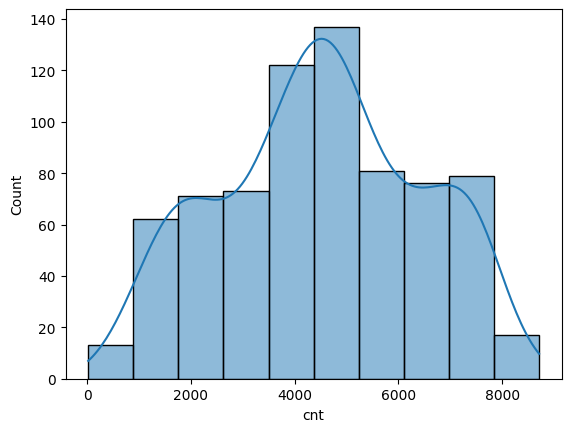

In [6]:
sns.histplot(data=df_bikes,x='cnt',bins=10,kde=True)

בדיקת מספר האופניים לפי חודשים- כמה האופניים נשכר בכל חודש. ניתן להסיק מזה איזה חודשים הפופולרים ביותר. כפי שניתן לראות כאן- בחודשי הקיץ

<Axes: xlabel='mnth', ylabel='cnt'>

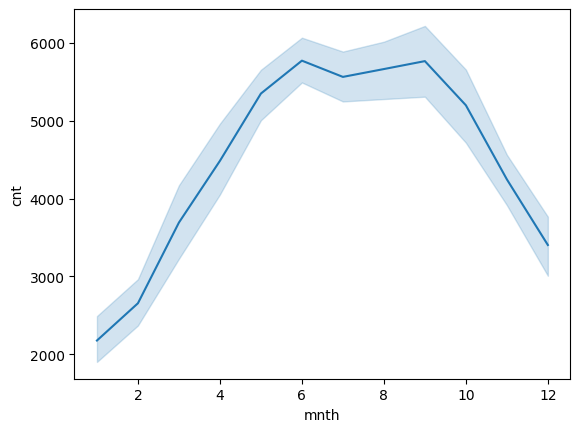

In [7]:
sns.lineplot(data=df_bikes, x='mnth', y='cnt')

 בדיקת הקשר בין טמפרטורת התחושה , נראות היום- מעונן, בהיר, ערפל וכו, לבין מספר האופניים שנלקחו.ניתן לראות שככל שהמעלות עולות, והיום יותר יפה- מספר האופניים עולה גם. יש ביניהם קשר לינארי.

<Axes: xlabel='atemp', ylabel='cnt'>

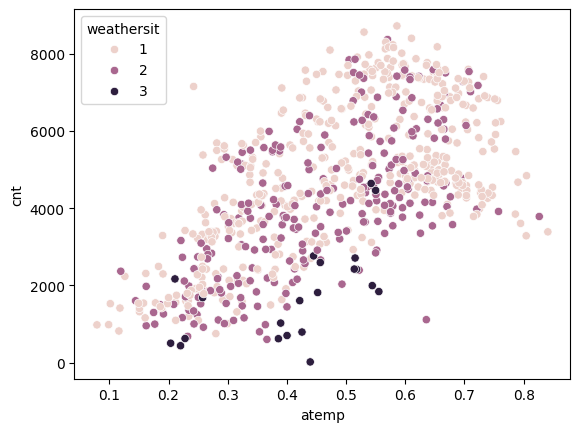

In [8]:
sns.scatterplot(x='atemp',y='cnt',data=df_bikes, hue='weathersit')

בדיקת הקשר בין מזג האויר- נראות היום, לבין כמות האופניים. ניתן לראות קשר ברור. ככל שהיום יותר יפה, מזג אויר טוב יותר- יותר אופניים נלקחו

<Axes: xlabel='weathersit', ylabel='cnt'>

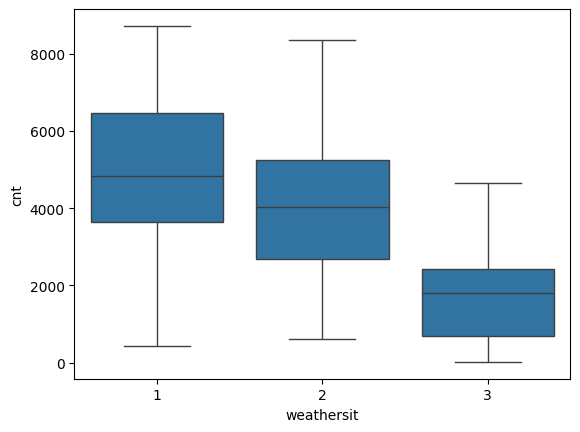

In [9]:
sns.boxplot(x='weathersit',y='cnt',data=df_bikes)

בדיקת מספר האופניים שנלקחו בחג/ ביום חול. ניתן לראות שבימי חול נלקחו יותר אופניים, החציון גבוה יותר

<Axes: xlabel='holiday', ylabel='cnt'>

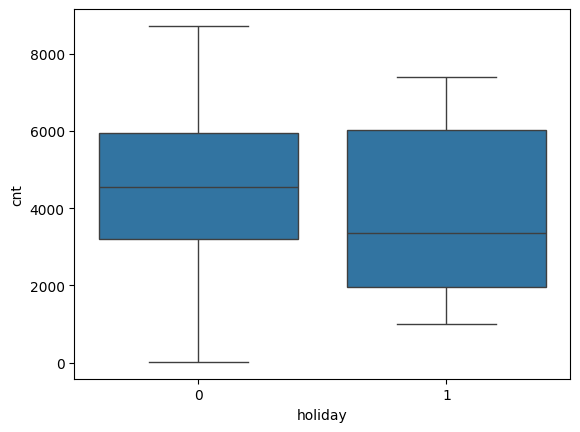

In [10]:
sns.boxplot(x='holiday',y='cnt',data=df_bikes)

מהתרשים ניתן לראות מגמה קלה של עלייה במספר ההשכרות לקראת סוף השבוע,
אך ההבדלים בין הימים אינם משמעותיים וקיימת חפיפה בין הקבוצות.
לכן הפיצ'ר בעל השפעה נמוכה יחסית.

<Axes: xlabel='weekday', ylabel='cnt'>

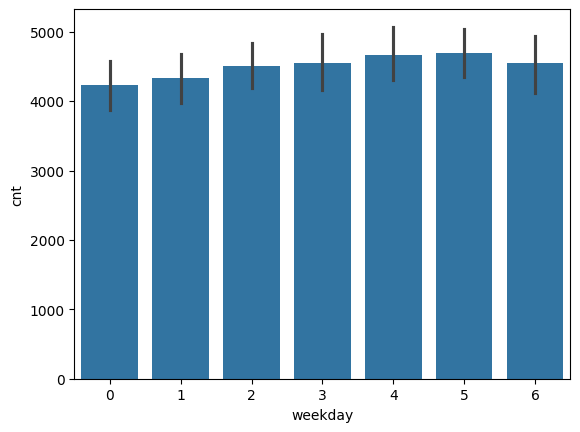

In [11]:
sns.barplot(x='weekday',y='cnt',data=df_bikes )

נבדוק כעת את הקורלציה של הפיצ'רים מול הטרגט, ונוכל להסיק מכך ומהתרשימים איזה פיצ'רים משפיעים ואילו פחות

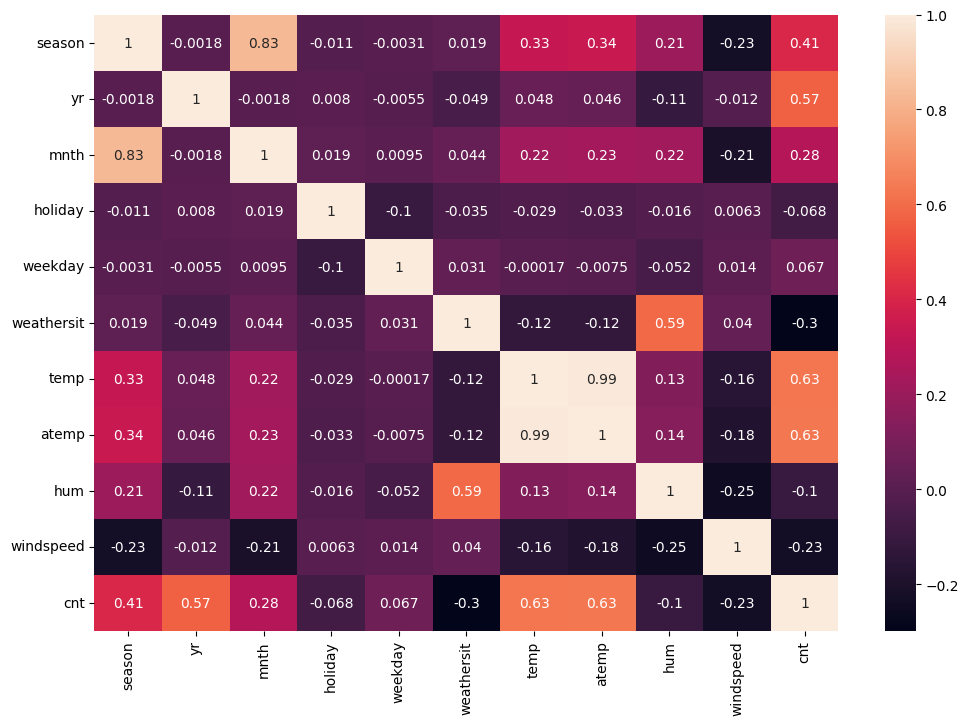

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(df_bikes.corr(numeric_only=True), annot=True)

plt.show()

הצגת הקורלציה של הפיצ'רים מול הטרגט בלבד

ניתן להסיק מכך איזה פיצ'רים פחות רלוונטים, לא משפיעים על הטרגט. נשמיט אותם בהמשך

In [39]:
corr = df_bikes.corr(numeric_only=True)
corr['cnt'].sort_values(ascending=False)

cnt           1.000000
atemp         0.631066
temp          0.627494
yr            0.566710
season        0.406100
mnth          0.279977
weekday       0.067443
holiday      -0.068348
hum          -0.100659
windspeed    -0.234545
weathersit   -0.297391
Name: cnt, dtype: float64

מוסיפה פיצ'ר חדש- טרנספורמציה של טמפרטורת תחושה. הפיצ'ר מאד הגיוני, ומשפיע על מספר האופניים- מחלק את טמפרטורת התחושה ל3: קר מאד, נעים, חם מאד

In [14]:
df_bikes['temp_group'] = pd.cut(
    df_bikes['atemp'],
    bins=[0, 0.3, 0.6, 1],
    labels=['cold','mild','hot']
)

In [15]:
df_bikes.temp_group.value_counts()

temp_group
mild    400
hot     198
cold    133
Name: count, dtype: int64

In [16]:
df_bikes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   season      731 non-null    int64   
 1   yr          731 non-null    int64   
 2   mnth        731 non-null    int64   
 3   holiday     731 non-null    int64   
 4   weekday     731 non-null    int64   
 5   weathersit  731 non-null    int64   
 6   temp        731 non-null    float64 
 7   atemp       731 non-null    float64 
 8   hum         731 non-null    float64 
 9   windspeed   731 non-null    float64 
 10  cnt         731 non-null    int64   
 11  temp_group  731 non-null    category
dtypes: category(1), float64(4), int64(7)
memory usage: 63.8 KB


נבדוק כעת- לאחר הוספת הפיצ'ר כמה הוא משפיע על מספר האופניים

ניתן לראות שהפיצ'ר החדש משפיע מאד. בקבוצות של טמפרטורה נעימה וחמה מספר האופניים גדל בפער. הפיצ'ר טוב ומשמעותי למודל.

<Axes: xlabel='temp_group', ylabel='cnt'>

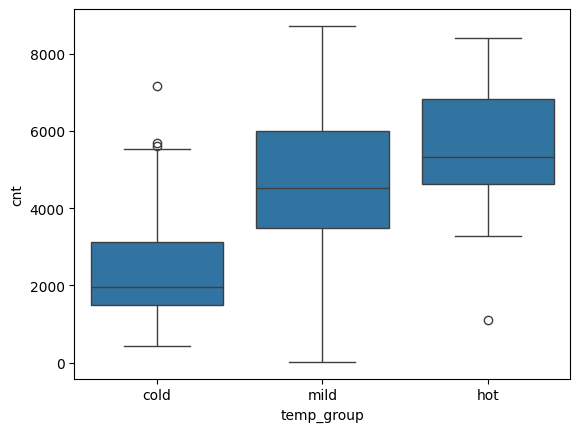

In [17]:
sns.boxplot(x='temp_group', y='cnt', data=df_bikes)

ניתן להסיק מהתרשימים ומהקורלציה שהפיצ'רים המשמעותיים ביותר לחיזוי הם: טמפרטורת תחושה (בדומה מאד לטמפרטורה. נבחר אחד מהם), טמפרטורת התחושה המחלוקת לקטגוריות (הפיצ'ר החדש) שנה, עונה, חודש, מזג אויר- נראות יום, ומהירות רוח(קצת פחות)

חלוקה ל X,Y -
לצורך האימון. 
השמטתי מX  עמודות שלא יועילו לחיזוי, כגון חג, יום בשבוע וטמפרטורה- 
כפילות של טמפרטורה מורגשת

In [18]:
y=df_bikes['cnt']
X = df_bikes.drop(columns=['cnt', 'weekday', 'holiday', 'temp'])

print(X.shape)
print(y.shape)

(731, 8)
(731,)


In [19]:
X.columns

Index(['season', 'yr', 'mnth', 'weathersit', 'atemp', 'hum', 'windspeed',
       'temp_group'],
      dtype='object')

חלוקה ל train, test ע"י train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(584, 8)
(147, 8)
(584,)
(147,)


קידוד- רק עבור הפיצ'ר החדש שהוא מטיפוס קטגוריה

שאר הפיצ'רים הקטגורליים טיפוסם מספרי, ולכאורה עבור עבודה עם רגרסיה לינארית היה צריך להמיר אותם לטיפוס קטגוריה ואז לקודד, השארת קטגוריות כמספרים עלולה ליצור פרשנות שגויה ברגרסיה לינארית. אך מכיוון שלאחר בדיקות של שתי הצורות ומודלים שונים, התקבל שבעבודה עם מודל הרנדוםפורסט וללא המרות לקטגוריה, כיוון שמודל זה איינו מניח קשר לינארי בין המשתנים, התקבלו התוצאות הטובות ביותר, R^2 הגבוה ביותר, החלטתי ללכת על הדרך הזאת.

במידה ובוחרים את מודל רגרסיה לינארית- ההמרה לקטגריות לפני הקידוד- ע"מ שפיצ'רים אלו יקודדו גם תראה כך:

categorical_cols = ['season','mnth','weathersit']

X_train[categorical_cols] = X_train[categorical_cols].astype('category')

X_test[categorical_cols] = X_test[categorical_cols].astype('category')

In [21]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [22]:
X_train.head()

,season,yr,mnth,weathersit,atemp,hum,windspeed,temp_group_mild,temp_group_hot
682,4,1,11,2,0.323225,0.662917,0.342046,True,False
250,3,0,9,3,0.555361,0.939565,0.192748,True,False
336,4,0,12,1,0.310604,0.612917,0.095783,True,False
260,3,0,9,1,0.490537,0.695000,0.178483,True,False
543,3,1,6,1,0.640792,0.360000,0.271775,False,True


מדובר בחיזוי מספרי, ולכן נתחיל עם רגרסיה לינארית כמודל בסיס ונבדוק תוצאות

In [23]:
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head()

,Actual,Predicted
703,6606,6370.149246
33,1550,1113.346580
300,3747,2860.919352
456,6041,4807.896708
633,7538,7120.829871


In [25]:
print("MAE:", mean_absolute_error(y_test, y_pred)) 
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 642.4997984944445
RMSE: 850.3059925748292
R2: 0.8196903976290832


מודל הרגרסיה הלינארית הביא תוצאות טובות. נבדוק מודלים מתקדמים יותר, במטרה לשפר את התוצאות

In [26]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred_tree = model.predict(X_test)

In [27]:
print("MAE:", mean_absolute_error(y_test, y_pred_tree)) 
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tree)))
print("R2:", r2_score(y_test, y_pred_tree))

MAE: 584.204081632653
RMSE: 854.3391128397968
R2: 0.8179758738040823


In [42]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)
y_pred_rnd = model.predict(X_test)

In [43]:
print("MAE:", mean_absolute_error(y_test, y_pred_rnd)) 
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rnd)))
print("R2:", r2_score(y_test, y_pred_rnd))

MAE: 455.5799319727891
RMSE: 691.3651347901495
R2: 0.8807980595928526


מסקנה:

מודל ה RandomForest מביא את התוצאות הטובות ביותר. הוא זה שנבחר

במודל זה ה R^2 מביא את התוצאות הטובות ביותר, המדד גבוה, זה אומר שהמודל מצליח להסביר טוב חלק גדול מהשונות במשתנה היעד, אז המודל טוב מאד

כמו כן גם שאר המדדים שנבדקו כאן- במודל זה התקבלו הכי נמוכים וזו המטרה

 בבדיקת הקשר בין חיזוי המודל לערכים האמיתיים ניתן לראות שהקשר לינארי. ביצועי המודל טובים

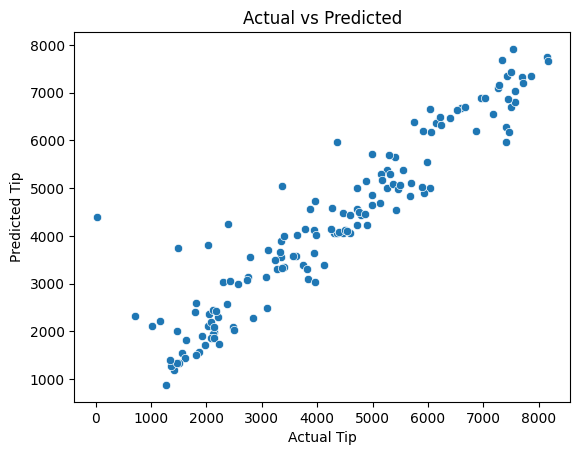

In [30]:
sns.scatterplot(x=y_test, y=y_pred_rnd)

plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.title("Actual vs Predicted")

plt.show()

In [31]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head()

,Actual,Predicted
703,6606,6669.68
33,1550,1545.97
300,3747,3382.38
456,6041,5007.65
633,7538,7916.43


ניתן לראות שהמאפיין המשפיע ביותר על ניבוי השכרת אופניים הוא טמפרטורת התחושה(atemp), לאחר מכן השנה- גם משמעותית, כל השאר פחות

In [44]:
importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False)

atemp              0.468095
yr                 0.288346
hum                0.073070
season             0.070647
windspeed          0.040208
mnth               0.037749
weathersit         0.019201
temp_group_mild    0.002030
temp_group_hot     0.000654
dtype: float64

מסקנות כלליות :



ככל שהטמפרטורה גבוהה יותר, מספר ההשכרות עולה.

 קיימת עלייה בהשכרות לאורך השנים, כפי שניתן לראות מהפיצ'ר yr.

ולגבי מזג האויר- נראות היום
 למרות שנמצא קשר בין מזג האוויר לבין מספר ההשכרות,
השפעתו נמוכה יחסית לעומת הטמפרטורה.
 